<a href="https://colab.research.google.com/github/VemuriPavanateja2007/Computer-Vision/blob/main/Practicals/CR_Pract_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd "/content/drive/MyDrive/Colab Notebooks/Computer Vision/Data For CV"

/content/drive/MyDrive/Colab Notebooks/Computer Vision/Data For CV


In [ ]:
# Load image
img = cv2.imread('road.jpg')

# Check if image was loaded successfully
if img is None:
    print("Error: Could not load image. Please check the file path 'road.jpg'.")
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Step 1: Edge detection (Hough needs edge pixels as input)
    edges = cv2.Canny(gray, 100, 200)

    # Step 2a: Standard Hough Transform
    lines_std = cv2.HoughLines(edges, 1, np.pi / 180, threshold=150)
    img_std = img.copy()
    if lines_std is not None:
        for rho, theta in lines_std[:, 0]:
            a, b = np.cos(theta), np.sin(theta)
            x0, y0 = a * rho, b * rho
            x1, y1 = int(x0 + 1000 * (-b)), int(y0 + 1000 * (a))
            x2, y2 = int(x0 - 1000 * (-b)), int(y0 - 1000 * (a))
            cv2.line(img_std, (x1, y1), (x2, y2), (0, 0, 255), 2)

    # Step 2b: Probabilistic Hough Transform
    lines_p = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=80,
                               minLineLength=50, maxLineGap=10)
    img_p = img.copy()
    if lines_p is not None:
        # Corrected: Iterate directly over lines_p to unpack x1, y1, x2, y2 for each line
        for x1, y1, x2, y2 in lines_p:
            cv2.line(img_p, (x1, y1), (x2, y2), (0, 255, 0), 2)

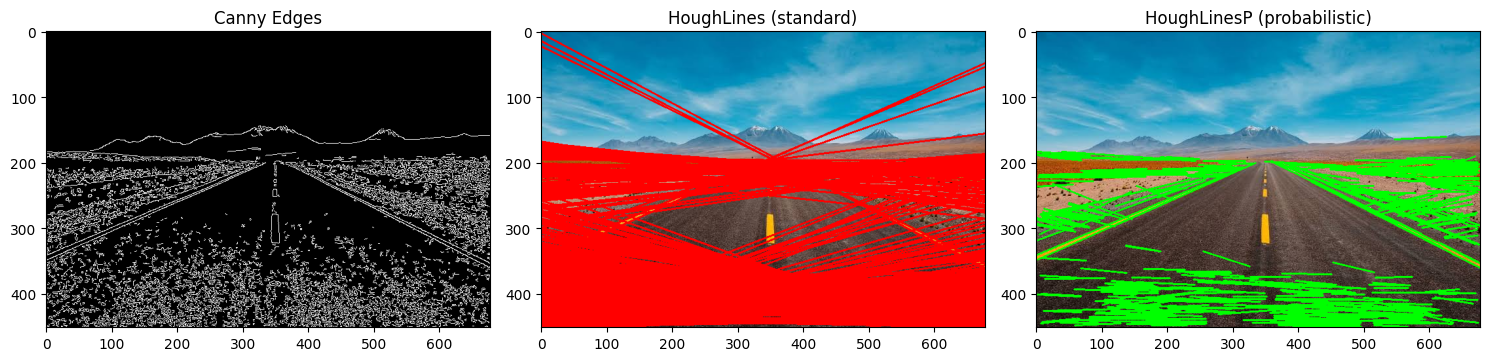

In [ ]:
# Display results
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1), plt.imshow(edges, cmap='gray'), plt.title('Canny Edges')
plt.subplot(1, 3, 2), plt.imshow(cv2.cvtColor(img_std, cv2.COLOR_BGR2RGB)), plt.title('HoughLines (standard)')
plt.subplot(1, 3, 3), plt.imshow(cv2.cvtColor(img_p, cv2.COLOR_BGR2RGB)), plt.title('HoughLinesP (probabilistic)')
plt.tight_layout()
plt.show()

